# Task 3: Data Analysis + Visualizations for WGU D598

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("D598 Data Set.xlsx")

In [4]:
df.head(4)

,Business ID,Business State,Total Long-term Debt,Total Equity,Debt to Equity,Total Liabilities,Total Revenue,Profit Margin
0,41872013,Kentucky,16889000.0,18046000.0,0.935886,25986000.0,136753000,0.023663
1,76232013,Iowa,6252000.0,18293621.0,0.341758,14474000.0,34226553,0.265015
2,160992013,Texas,19200000.0,177858000.0,0.107951,72787000.0,384196000,0.130413
3,197452013,Delaware,117592000.0,278773000.0,0.421820,558749000.0,444306000,0.196768


## 3. Duplicate Detection

In [7]:
duplicate_rows = df[df.duplicated()]
duplicate_rows

print("Total duplicate rows:", duplicate_rows.shape[0])

Total duplicate rows: 0


## 4. Group by State & Descriptive Stats

In [11]:
numeric_cols = df.select_dtypes(include='number').columns
grouped_stats = df.groupby('Business State')[numeric_cols].agg(['mean','median','min','max']).reset_index()
print("Grouped Descriptive Statistics by State:")
grouped_stats.head(5)

Grouped Descriptive Statistics by State:


Business State   Business ID                                         \
                          mean        median         min          max   
0        Alabama  1.599117e+09  1.599117e+09   422282013   2775952013   
1        Arizona  9.445082e+09  9.445082e+09  9445082013   9445082013   
2       Arkansas  8.411162e+09  8.411162e+09  7982872013   8839452013   
3     California  1.063053e+10  1.034300e+10  7192742013  14733342013   
4       Colorado  9.966963e+09  1.008177e+10  3194582013  14214612013   

  Total Long-term Debt                                         Total Equity  \
                  mean       median         min           max          mean   
0         6.743890e+08  674389000.0   5314000.0  1.343464e+09  1.441039e+09   
1         6.508800e+07   65088000.0  65088000.0  6.508800e+07  5.915300e+07   
2         8.960450e+07   89604500.0  70366000.0  1.088430e+08  1.082420e+08   
3         3.273964e+07    4721500.0     15000.0  3.349970e+08  4.535982e+07   
4         8.470025e+07   29327000.0   3375000.0  3.753220e+08  2.007589e+08   

   ... Total Liabilities               Total Revenue                          \
   ...               min           max          mean       median        min   
0  ...        23698000.0  3.764193e+09  6.968309e+08  696830858.0  137344716   
1  ...       110938000.0  1.109380e+08  2.155800e+08  215580000.0  215580000   
2  ...       213356000.0  2.144080e+08  4.789090e+08  478909000.0  402813000   
3  ...         2658000.0  7.888110e+08  8.869559e+07   37531500.0    1100539   
4  ...         6787000.0  5.822750e+08  2.486542e+08  202399000.0    7616000   

              Profit Margin                                
          max          mean    median       min       max  
0  1256317000      0.403732  0.403732  0.297094  0.510371  
1   215580000      0.206902  0.206902  0.206902  0.206902  
2   555005000      0.098319  0.098319  0.073156  0.123482  
3   276869000      0.287947  0.301992 -0.084923  0.505955  
4   696473000      0.346033  0.314631  0.124017  0.655796  

[5 rows x 29 columns]

## 5. Filter Negative Debt-to-Equity

In [13]:
negative_de_ratio = df[df['Debt to Equity'] < 0]
print("Businesses with Negative Debt-to-Equity Ratio:")
display(negative_de_ratio)

Businesses with Negative Debt-to-Equity Ratio:


,Business ID,Business State,Total Long-term Debt,Total Equity,Debt to Equity,Total Liabilities,Total Revenue,Profit Margin
18,934562013,Ohio,263880000.0,-111297000.0,-2.370953,592174000.0,719783000,0.320697
57,8343652013,Washington,10603000.0,-13271658.0,-0.798921,16625000.0,8949401,0.448119
87,9323722013,California,21560000.0,-15691000.0,-1.374036,30048000.0,37782000,0.505955
109,10919832013,Utah,2010000.0,-3602481.0,-0.557949,6302000.0,17757388,0.732562
117,11245242013,California,556000.0,-2063203.0,-0.269484,3819000.0,1100539,-0.084923
142,14535932013,Montana,16459000.0,-3842372.0,-4.283552,32720000.0,33073414,0.582444
143,14639722013,New York,187000.0,-13037879.0,-0.014343,15900000.0,2389053,0.300978


## 6. Calculate Debt-to-Income Ratio

In [16]:
df['Debt-to-Income'] = df['Total Long-term Debt'] / df['Total Revenue']
print("Debt-to-Income Ratio Added:")
display(df[['Business ID','Debt-to-Income']].head())

Debt-to-Income Ratio Added:


,Business ID,Debt-to-Income
0,41872013,0.123500
1,76232013,0.182665
2,160992013,0.049974
3,197452013,0.264664
4,241042013,0.036268


# 7. Visualizations

### Visualization 1: Average Revenue by State (Bar chart)

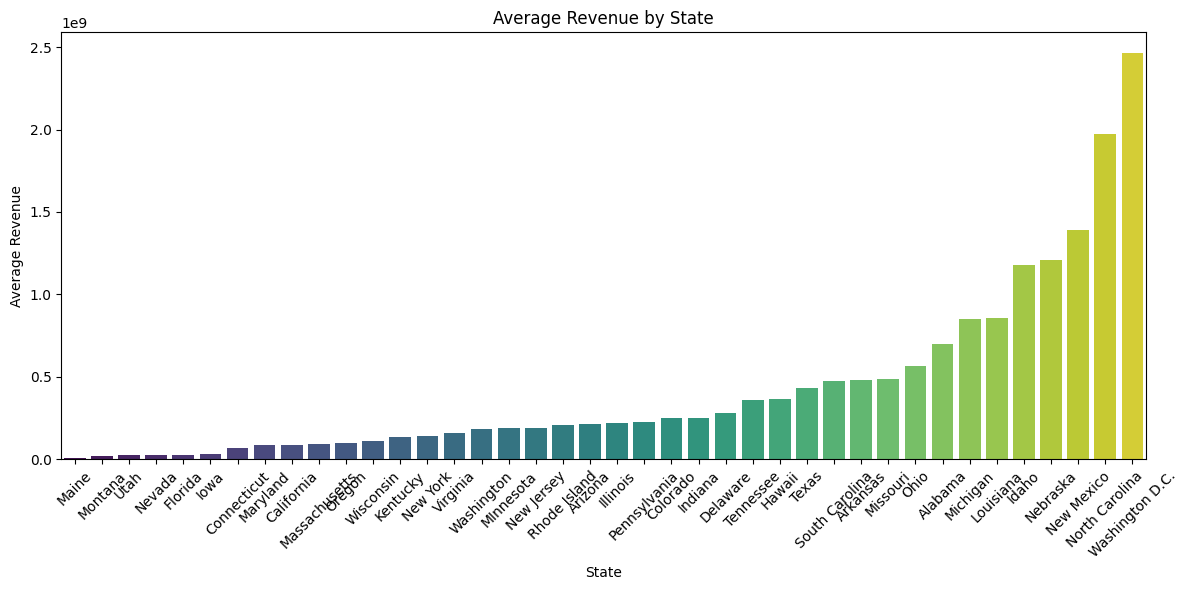

In [19]:
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(12,6))
avg_revenue_state = df.groupby('Business State')['Total Revenue'].mean().sort_values()
sns.barplot(x=avg_revenue_state.index, y=avg_revenue_state.values, palette="viridis")
plt.title("Average Revenue by State")
plt.xlabel("State")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visualization 2: Histogram of Debt-to-Equity Ratios

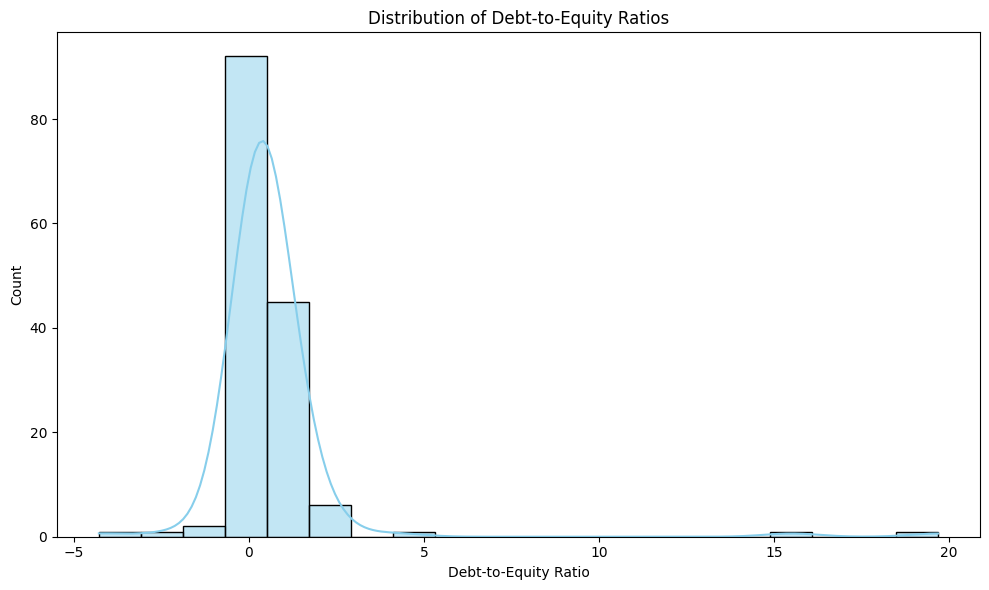

In [20]:
plt.figure(figsize=(10,6))
sns.histplot(df['Debt to Equity'], bins=20, kde=True, color="skyblue")
plt.title("Distribution of Debt-to-Equity Ratios")
plt.xlabel("Debt-to-Equity Ratio")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Visualization 3: Scatter Plot - Debt-to-Income vs Total Revenue

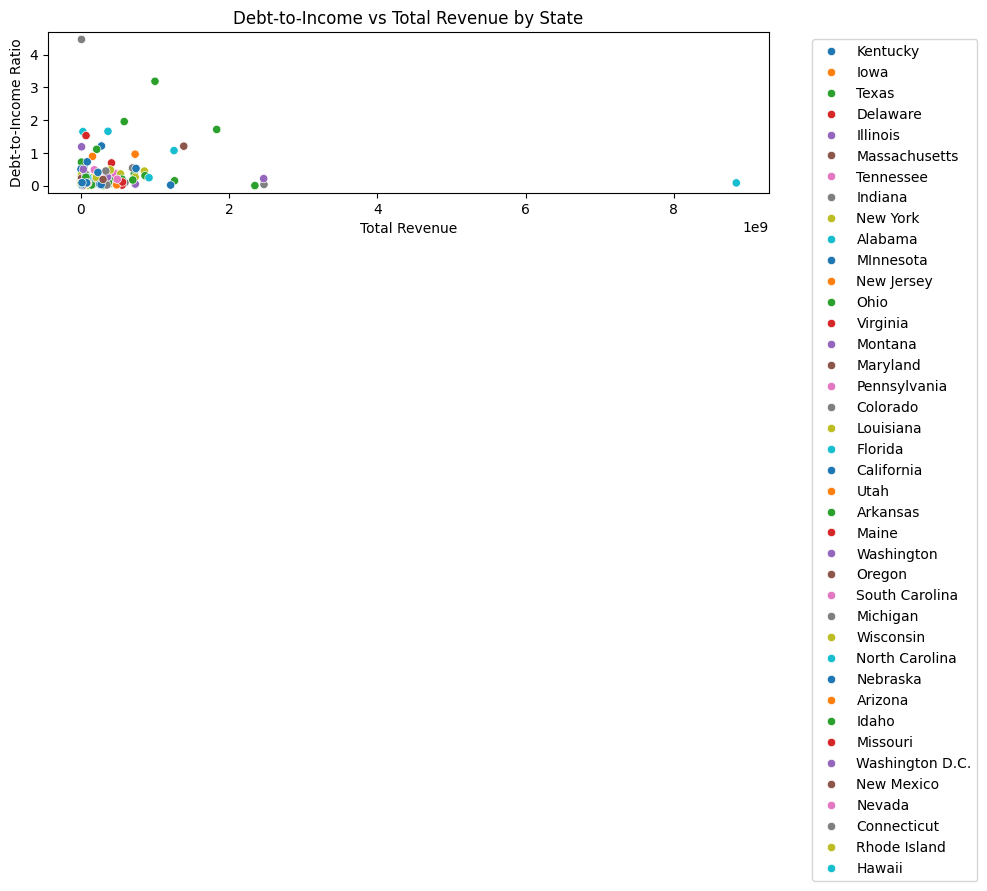

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Total Revenue', y='Debt-to-Income', hue='Business State', palette='tab10')
plt.title("Debt-to-Income vs Total Revenue by State")
plt.xlabel("Total Revenue")
plt.ylabel("Debt-to-Income Ratio")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

## Visualization 4: Pie Chart - Companies per State

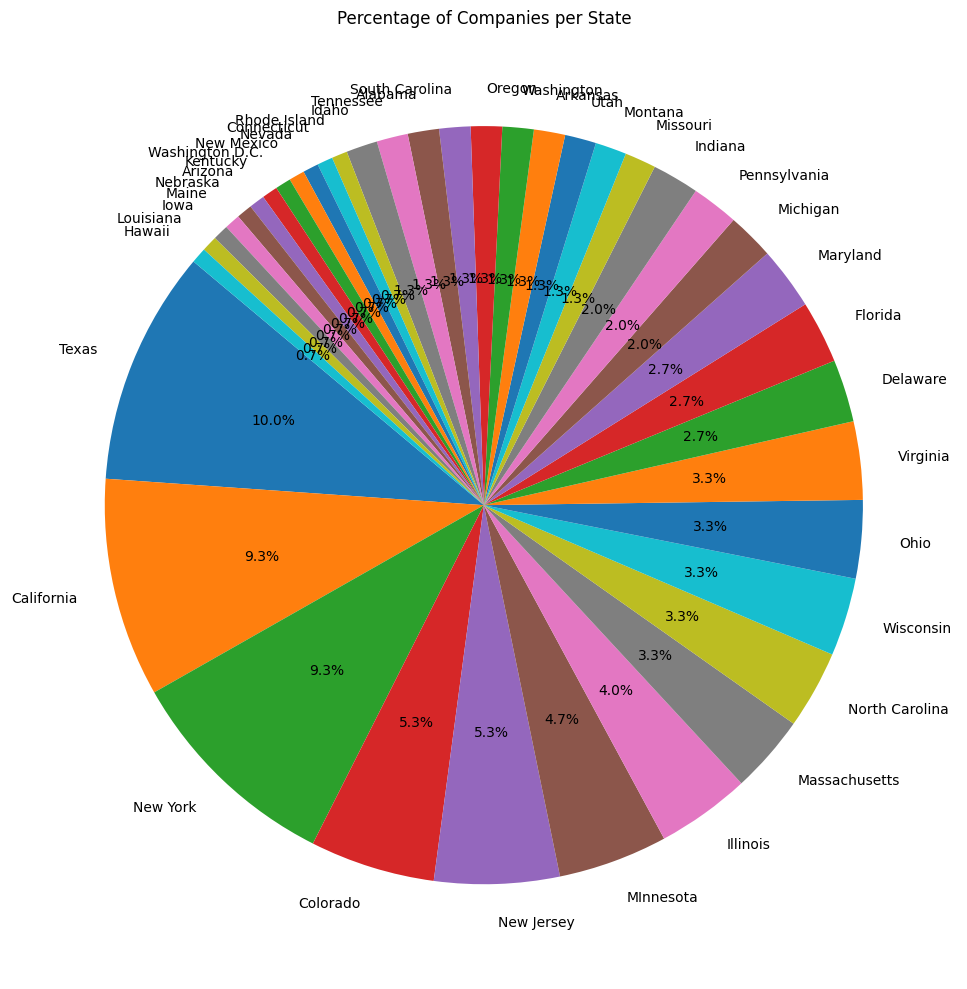

In [28]:
companies_per_state = df['Business State'].value_counts()
plt.figure(figsize=(10,10))
plt.pie(companies_per_state, labels=companies_per_state.index, autopct='%1.1f%%', startangle=140)
plt.title("Percentage of Companies per State")
plt.tight_layout()
plt.show()